<a href="https://colab.research.google.com/github/ubuntumel/AI_Colab_DeepLearning/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://colab.research.google.com/drive/1Uu7OjEEmeSVMuuxmsPfI59jUw6IcnthO?usp=sharing

Author: Meliton Rojas

In [ ]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import Flatten, Conv2D, MaxPooling2D

from matplotlib import pyplot as plt
import pandas as pd

In [ ]:
(x_train, y_train), (x_valid, y_valid) = mnist.load_data()

In [ ]:
x_train = x_train.reshape(60000, 28, 28, 1).astype('float32')
x_valid = x_valid.reshape(10000, 28, 28, 1).astype('float32')

In [ ]:
x_train /= 255
x_valid /= 255

In [ ]:
n_classes = 10
y_train = keras.utils.to_categorical(y_train, n_classes)
y_valid = keras.utils.to_categorical(y_valid, n_classes)

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(n_classes, activation='softmax'))


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8424 - loss: 0.4969 - val_accuracy: 0.9837 - val_loss: 0.0513
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9731 - loss: 0.0878 - val_accuracy: 0.9867 - val_loss: 0.0397
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9804 - loss: 0.0636 - val_accuracy: 0.9891 - val_loss: 0.0342
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9831 - loss: 0.0541 - val_accuracy: 0.9899 - val_loss: 0.0297
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9870 - loss: 0.0396 - val_accuracy: 0.9903 - val_loss: 0.0314
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9887 - loss: 0.0362 - val_accuracy: 0.9910 - val_loss: 0.0295
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9895 - loss: 0.0332 - val_accuracy: 0.9911 - val_loss: 0.0291
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9891 - loss: 0.0326 - val_accuracy: 

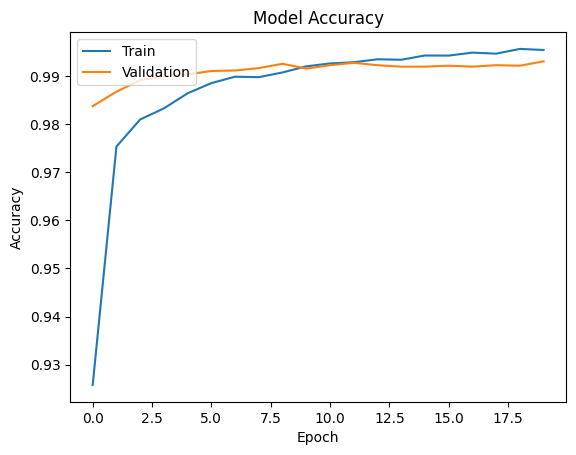

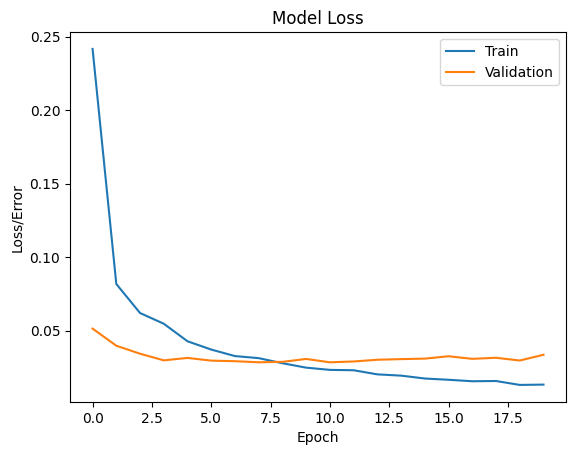

In [ ]:
history = model.fit(x_train, y_train, batch_size=128, epochs=20, verbose=1, validation_data=(x_valid, y_valid))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss/Error')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

#print(history.history.keys())
#pd.DataFrame(history.history).plot(figsize=(8, 5))
#plt.show()